In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# pip install scikit-surprise

In [ ]:
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
import matplotlib.pyplot as plt

In [ ]:
ratings = pd.read_csv('/content/drive/MyDrive/recom system/ratings.csv')
movies = pd.read_csv('/content/drive/MyDrive/recom system/movies.csv')

In [ ]:
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [ ]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [ ]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
print(num_users, num_movies)

610 9724


In [ ]:
ratings.shape

(100836, 4)

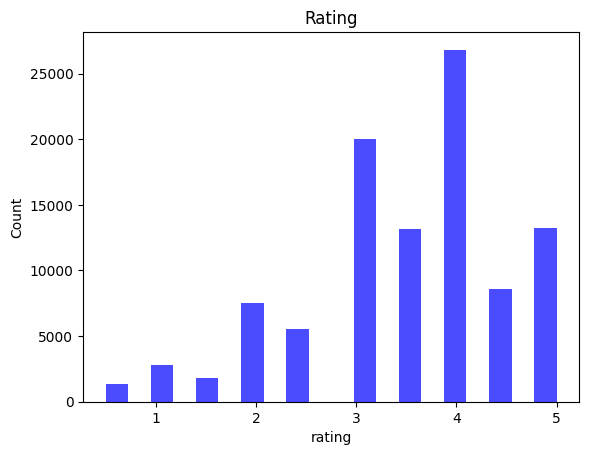

In [ ]:
plt.hist(ratings['rating'], bins=20, color='blue', alpha=0.7)
plt.title('Rating')
plt.xlabel('rating')
plt.ylabel('Count')
plt.show()

In [ ]:
active_users = ratings['userId'].value_counts()[ratings['userId'].value_counts() >= 20].index
active_movies = ratings['movieId'].value_counts()[ratings['movieId'].value_counts() >= 20].index

In [ ]:
# ratings['userId'].value_counts()[ratings['userId'].value_counts() >= 20].index

In [ ]:
filtered_ratings = ratings[(ratings['userId'].isin(active_users)) & (ratings['movieId'].isin(active_movies))]

In [ ]:
active_users, active_movies, filtered_ratings

(Index([414, 599, 474, 448, 274, 610,  68, 380, 606, 288,
        ...
        147, 257, 406, 431, 278, 442, 569, 320, 576,  53],
       dtype='int64', name='userId', length=610),
 Index([  356,   318,   296,   593,  2571,   260,   480,   110,   589,   527,
        ...
         1033, 49278,  6888,   737,   308,    69, 96821,  4623,    18,  1429],
       dtype='int64', name='movieId', length=1297),
         userId  movieId  rating   timestamp
 0            1        1     4.0   964982703
 1            1        3     4.0   964981247
 2            1        6     4.0   964982224
 3            1       47     5.0   964983815
 4            1       50     5.0   964982931
 ...        ...      ...     ...         ...
 100803     610   148626     4.0  1493847175
 100808     610   152081     4.0  1493846503
 100829     610   164179     5.0  1493845631
 100830     610   166528     4.0  1493879365
 100834     610   168252     5.0  1493846352
 
 [67898 rows x 4 columns])

In [ ]:
# svd
svd = SVD()
#crossvl
cv_result = cross_validate(svd, data, measures=['rmse', 'mae'], cv=5)

In [ ]:
cv_result

{'test_rmse': array([0.87655394, 0.87823367, 0.8803849 , 0.86346639, 0.87378539]),
 'test_mae': array([0.67074029, 0.67432741, 0.67654697, 0.6634004 , 0.67134239]),
 'fit_time': (1.9581432342529297,
  2.9957399368286133,
  5.076417446136475,
  1.469395637512207,
  2.6440954208374023),
 'test_time': (0.37671422958374023,
  0.4011383056640625,
  0.5087671279907227,
  0.25780677795410156,
  0.25540781021118164)}

In [ ]:
param_grid = {
    'n_factors': [50, 100, 150],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.1, 0.2]
}

In [ ]:
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
grid_search.fit(data)

In [ ]:
grid_search.best_params['rmse']

{'n_factors': 150, 'lr_all': 0.01, 'reg_all': 0.1}

In [ ]:
best_model = grid_search.best_estimator['rmse']

In [ ]:
trainset, testset = train_test_split(data, test_size=0.2)

In [ ]:
best_model.fit(trainset)

In [ ]:
pred = best_model.test(testset)

In [ ]:
# pred

In [ ]:
accuracy.rmse(pred)

RMSE: 0.8671


0.8670640906716609

In [ ]:
def recommend_movies(user_id, model, movies, n_recommendations=10):
  #S1
  all_movies_ids = movies['movieId'].unique()
  rated_movie_ids = ratings[ratings['userId'] == user_id]['movieId']
  unrated_movie_ids = [mid for mid in all_movies_ids if mid not in rated_movie_ids.values]

  # pred
  pred = [model.predict(user_id, mid) for mid in unrated_movie_ids]
  pred.sort(key=lambda x: x.est, reverse=True)

  # select
  top_pred = pred[:n_recommendations]
  top_movie_ids = [pred.iid for pred in top_pred]

  # name
  recommended_movies = movies[movies['movieId'].isin(top_movie_ids)]
  recommended_movies['prediction rate'] = [pred.est for pred in top_pred]

  return recommended_movies.sort_values(by='prediction rate', ascending=False)

In [ ]:
user_id = 5
recommended_movies = recommend_movies(user_id, best_model, movies, n_recommendations=10)
print(f"Recommended Movies for User {user_id}:")
print(recommended_movies)

Recommended Movies for User 5:
      movieId                                             title  \
906      1204                         Lawrence of Arabia (1962)   
947      1248                              Touch of Evil (1958)   
975      1276                             Cool Hand Luke (1967)   
982      1283                                  High Noon (1952)   
1616     2160                            Rosemary's Baby (1968)   
2462     3275                       Boondock Saints, The (2000)   
6648    56782                        There Will Be Blood (2007)   
7704    89904                                 The Artist (2011)   
9301   158966                          Captain Fantastic (2016)   
9618   177593  Three Billboards Outside Ebbing, Missouri (2017)   

                           genres  prediction rate  
906           Adventure|Drama|War         4.287262  
947      Crime|Film-Noir|Thriller         4.265513  
975                         Drama         4.206232  
982                

<ipython-input-28-8c9175fd8290>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommended_movies['prediction rate'] = [pred.est for pred in top_pred]
